<a href="https://colab.research.google.com/github/Prabhsimar2104/DL-Project/blob/main/CustomCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q tensorflow keras matplotlib seaborn scikit-learn opencv-python
!pip install -q timm

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
base_path = "/content/drive/MyDrive/archive/chest_xray"

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
img_size = 224
batch_size = 32

In [22]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1
)

# TRAIN DATA
train_data = train_datagen.flow_from_directory(
    base_path + '/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

# VALIDATION DATA (FROM TRAIN)
val_data = train_datagen.flow_from_directory(
    base_path + '/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    base_path + '/test',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 4695 images belonging to 2 classes.
Found 521 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [23]:
images, labels = next(train_data)

print("Image shape:", images.shape)
print("Labels shape:", labels.shape)

Image shape: (32, 224, 224, 3)
Labels shape: (32,)


In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report

In [25]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_custom_cnn.h5',
    monitor='val_accuracy',
    save_best_only=True
)

In [28]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.7736 - loss: 0.5354 

147/147 ━━━━━━━━━━━━━━━━━━━━ 2519s 17s/step - accuracy: 0.8400 - loss: 0.3672 - val_accuracy: 0.8618 - val_loss: 0.2929
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9005 - loss: 0.2550

147/147 ━━━━━━━━━━━━━━━━━━━━ 126s 857ms/step - accuracy: 0.9014 - loss: 0.2495 - val_accuracy: 0.8733 - val_loss: 0.2733
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 127s 860ms/step - accuracy: 0.9044 - loss: 0.2348 - val_accuracy: 0.8733 - val_loss: 0.2634
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.9150 - loss: 0.2022

147/147 ━━━━━━━━━━━━━━━━━━━━ 128s 871ms/step - accuracy: 0.9188 - loss: 0.1975 - val_accuracy: 0.8983 - val_loss: 0.2294
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.9227 - loss: 0.2023

147/147 ━━━━━━━━━━━━━━━━━━━━ 131s 887ms/step - accuracy: 0.9223 - loss: 0.1964 - val_accuracy: 0.9328 - val_loss: 0.2053
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 133s 903ms/step - accuracy: 0.9291 - loss: 0.1847 - val_accuracy: 0.9136 - val_loss: 0.2218
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 131s 887ms/step - accuracy: 0.9327 - loss: 0.1745 - val_accuracy: 0.8868 - val_loss: 0.2544
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 125s 847ms/step - accuracy: 0.9423 - loss: 0.1565 - val_accuracy: 0.9251 - val_loss: 0.1898
Epoch 9/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 127s 867ms/step - accuracy: 0.9348 - loss: 0.1595 - val_accuracy: 0.9232 - val_loss: 0.1906
Epoch 10/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 125s 854ms/step - accuracy: 0.9453 - loss: 0.1513 - val_accuracy: 0.9290 - val_loss: 0.1645


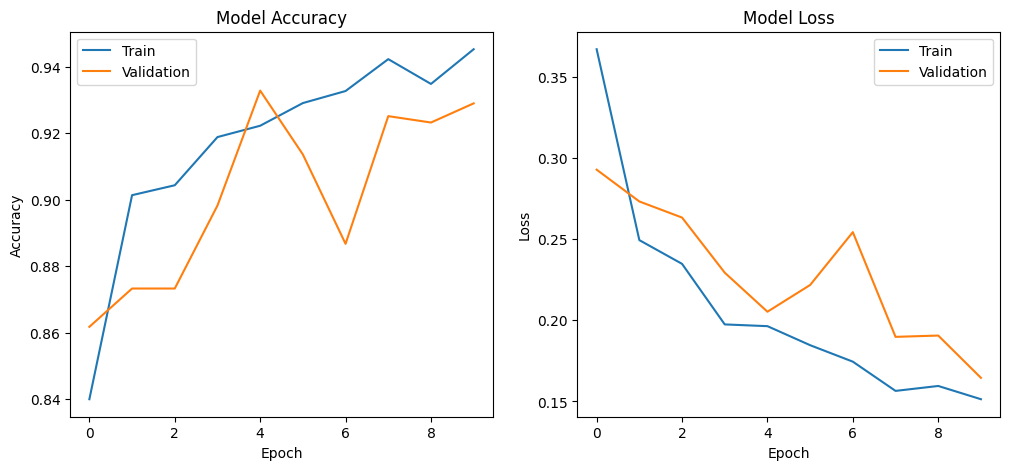

In [29]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [30]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 347s 18s/step - accuracy: 0.8798 - loss: 0.3203
Test Accuracy: 0.879807710647583


In [31]:
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int).flatten()

y_true = test_data.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 378ms/step


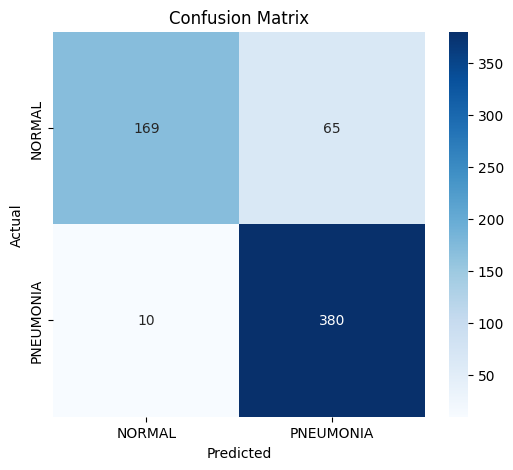

In [32]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','PNEUMONIA'],
            yticklabels=['NORMAL','PNEUMONIA'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [33]:
print(classification_report(y_true, y_pred, target_names=['NORMAL','PNEUMONIA']))

              precision    recall  f1-score   support

      NORMAL       0.94      0.72      0.82       234
   PNEUMONIA       0.85      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.85      0.86       624
weighted avg       0.89      0.88      0.88       624



In [34]:
print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.879807710647583


In [35]:
model.save('/content/drive/MyDrive/best_custom_cnn.h5')